In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import warnings 
warnings.filterwarnings('ignore')

sns.set_theme(style = 'whitegrid', font_scale = 1.1)

In [3]:
df = pd.read_csv('data/processed/spotify_clean.csv')
X = df.drop('track_genre', axis = 1)
y_raw = df['track_genre']

le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

print(f"Train: {X_train.shape[0]} треков | Test: {X_test.shape[0]} треков")
print(f"Классы: {class_names}")


Train: 7989 треков | Test: 1998 треков
Классы: ['acoustic' 'afrobeat' 'alt-rock' 'ambient' 'bluegrass' 'cantopop'
 'chicago-house' 'disney' 'forro' 'tango']


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter = 1000, random_state = 42),
    'Random Forest': RandomForestClassifier(n_estimators = 150, random_state = 42),
    'KNN': KNeighborsClassifier(n_neighbors = 7),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators = 150, random_state = 42)
}

In [6]:
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average = 'macro')

    results[name] = {'acc': acc, 'f1': f1, 'model': model, 'preds': y_pred}
    print(f"{name} | Accuracy: {acc:.4f} | F1-Macro: {f1:.4f}")

Logistic Regression | Accuracy: 0.5981 | F1-Macro: 0.5937
Random Forest | Accuracy: 0.7733 | F1-Macro: 0.7715
KNN | Accuracy: 0.6757 | F1-Macro: 0.6737
Gradient Boosting | Accuracy: 0.7683 | F1-Macro: 0.7680


In [9]:
from sklearn.model_selection import cross_val_score
print('Считаем стабильные метрики через CV')

cv_results = {}

for name, model in models.items():
    acc_cv = cross_val_score(model, X_train_scaled, y_train, cv = 5, scoring = 'accuracy')
    f1_cv = cross_val_score(model, X_train_scaled, y_train, cv = 5, scoring = 'f1_macro')

    cv_results[name] = {
    'acc': acc_cv.mean(),
    'f1': f1_cv.mean(),
    'acc_std': acc_cv.std(),
    'f1_std': f1_cv.std()
    }

    print(f"{name}: Accuracy = {acc_cv.mean():.4f}+-{acc_cv.std():.3f} | F1 = {f1_cv.mean():.4f}+-{f1_cv.std():.3f} ")

df_metrics = pd.DataFrame(cv_results).T[['acc', 'f1']].reset_index()
df_metrics.columns = ['Model', 'Accuracy', 'F1_Macro']

Считаем стабильные метрики через CV
Logistic Regression: Accuracy = 0.6107+-0.006 | F1 = 0.6062+-0.006 
Random Forest: Accuracy = 0.7733+-0.010 | F1 = 0.7712+-0.010 
KNN: Accuracy = 0.6838+-0.010 | F1 = 0.6818+-0.010 
Gradient Boosting: Accuracy = 0.7642+-0.011 | F1 = 0.7637+-0.011 


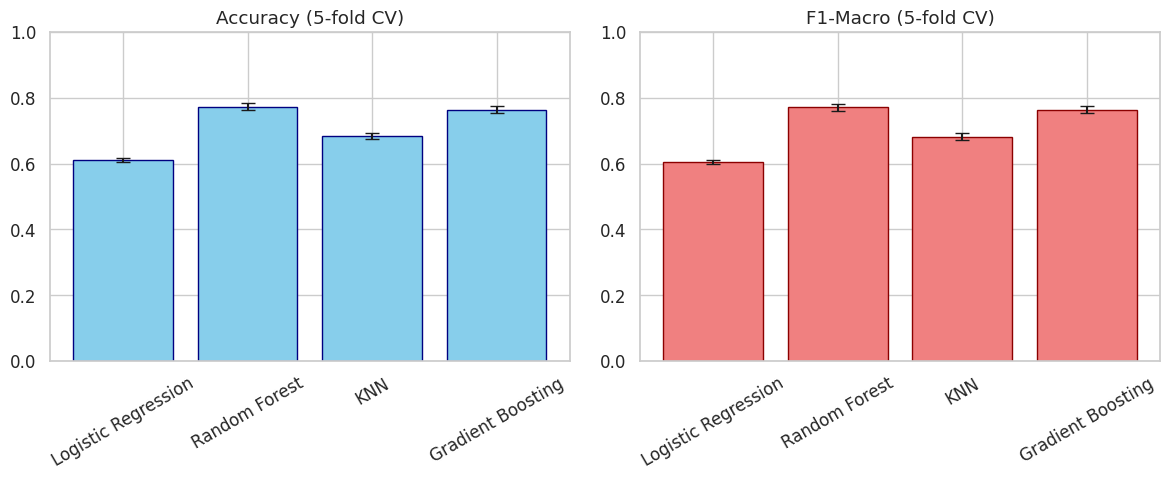

In [11]:
df_cv = pd.DataFrame(cv_results).T[['acc', 'f1', 'acc_std', 'f1_std']].reset_index()
df_cv.columns = ['Model', 'Accuracy', 'F1-Macro', 'Acc_Std', 'F1_Std']

fig, axes = plt.subplots(1, 2, figsize = (12, 5))

axes[0].bar(df_cv['Model'], df_cv['Accuracy'], yerr=df_cv['Acc_Std'], 
            capsize=5, color='skyblue', edgecolor='navy')
axes[0].set_title('Accuracy (5-fold CV)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 1)

axes[1].bar(df_cv['Model'], df_cv['F1-Macro'], yerr=df_cv['F1_Std'], 
            capsize=5, color='lightcoral', edgecolor='darkred')
axes[1].set_title('F1-Macro (5-fold CV)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

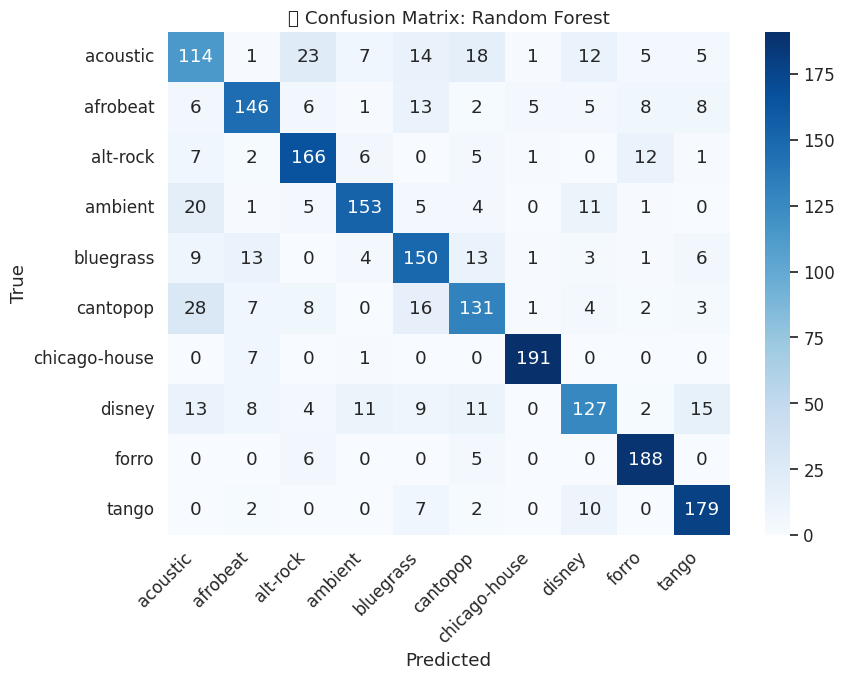

In [ ]:
best_name = df_metrics.loc[df_metrics['F1-Macro'].idxmax(), 'Model']
best_preds = results[best_name]['preds']

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix: {best_name}')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

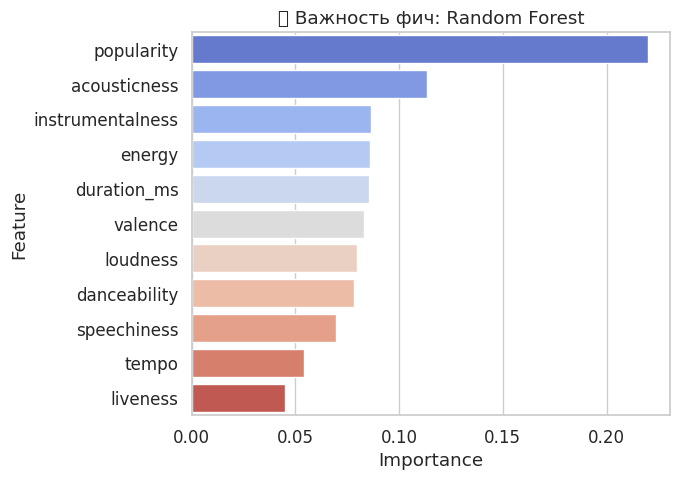


🏆 Лучшая модель: Random Forest


In [ ]:
if best_name in ['Random Forest', 'Gradient Boosting']:
    importances = results[best_name]['model'].feature_importances_
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
    feat_imp = feat_imp.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(7, 5))
    sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='coolwarm')
    plt.title(f'🔍 Важность фич: {best_name}')
    plt.tight_layout()
    plt.show()
else:
    print("📝 Для этой модели importance считается иначе. Можно добавить позже.")
    
print(f"\n🏆 Лучшая модель: {best_name}")